<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Inference 1 -- Borexino: Fitting theta12 to Real Solar Neutrino Data
---
A self-contained gradient-based inference of a gradient-based fit of the solar mixing angle $\theta_{12}$ to the real electron-neutrino survival probability measurements published by the Borexino collaboration,

> Borexino Collaboration, *"Comprehensive measurement of pp-chain solar neutrinos"*, Nature 562, 505-510 (2018), [doi:10.1038/s41586-018-0624-y](https://doi.org/10.1038/s41586-018-0624-y)

using the four measured $P_{ee}$ values (pp, $^7$Be, pep, $^8$B), each with a published asymmetric uncertainty, from `data/detector/borexino/probability/nature2018_pee_points.csv` -- then extends the same real oscillation model to predicted **event counts** (a full forward-folding chain through the real nu-e elastic-scattering cross section, detector response, and exposure), compared qualitatively against Borexino's own real low-energy recoil spectrum.

---

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Pre-Fit-Baseline-NuFIT-vs-Borexino) | **Pre-Fit Baseline: NuFIT vs Borexino** |
| [4](#4.-Fit-theta12-to-Real-Borexino-Data) | **Fit theta12 to Real Borexino Data** |
| [5](#5.-Goodness-of-Fit) | **Goodness of Fit** |
| [6](#6.-Two-Parameter-Fit-theta12-and-DeltamSq21) | **Two-Parameter Fit: theta12 and DeltamSq21** |
| [7](#7.-Real-Event-Rate-Shape-Comparison) | **Real Event-Rate Shape Comparison** |
| [8](#8.-Summary) | **Summary** |


## 0. Theoretical Framework

This stage evaluates theoretical framework with the likelihood, physical priors, covariance model, and numerical controls defined above.


### 0.1 The Observable

For a $^8$B/pep/$^7$Be/pp solar $\nu_e$ propagating adiabatically through the Sun's electron density, the survival probability averaged over the fast oscillation phase is

$$P_{ee}(E_\nu) \;=\; \cos^4\theta_{13}\Big[\cos^2\theta_{12}^M\cos^2\theta_{12} + \sin^2\theta_{12}^M\sin^2\theta_{12}\Big] \;+\; \sin^4\theta_{13}, \qquad
\tan(2\theta_{12}^M) = \frac{\sin(2\theta_{12})}{\cos(2\theta_{12}) - \dfrac{2\sqrt{2}\,G_F n_e E_\nu}{\Delta m^2_{21}}},$$

with $\theta_{12}^M$ the matter-modified mixing angle at the production point. Only $\theta_{12}$/$\theta_{13}$ enter; $\theta_{23}$/$\delta_{13}$ are fixed at a reference value throughout, since they affect only the $\mu/\tau$ rows of the PMNS matrix.


### 0.2 Fit Statistic and Uncertainty

The $P_{ee}$-point fits below (Sections 3-6) minimize the asymmetric $\chi^2$

$$\chi^2(\theta_{12}) = \sum_{i=1}^{4} \left(\frac{P_{ee}^{\rm pred}(E_i;\theta_{12}) - P_{ee}^{\rm obs}(E_i)}{\sigma_i}\right)^{\!2}, \qquad \sigma_i = \sigma_{+,i}\text{ or }\sigma_{-,i}\text{ by the sign of the residual},$$

via `torch.optim.LBFGS` with the exact autograd gradient $\partial\chi^2/\partial\theta_{12}$, reporting the Laplace-approximation uncertainty $\sigma_{\hat\theta_{12}} = \big(2\,\partial^2\chi^2/\partial\theta_{12}^2\big)^{-1/2}$ at the minimum (autograd Hessian, not finite differences).


### 0.3 Goodness of Fit

With $N=4$ data points and $k$ free parameters, the fit has $\nu=N-k$ degrees of freedom. Under the standard large-sample approximation, $\chi^2_{\rm min}$ at the true parameters is itself $\chi^2$-distributed with $\nu$ degrees of freedom, giving the $p$-value

$$p = P\big(\chi^2_\nu \ge \chi^2_{\rm min}\big) = 1 - F_{\chi^2_\nu}(\chi^2_{\rm min}),$$

evaluated below with `scipy.stats.chi2.sf`.


### 0.4 From P_ee(E) to Predicted Event Counts

Section 7 extends the same oscillation model to Borexino's actual observable, a recoil-electron count spectrum, via $\nu+e^-\to\nu+e^-$ elastic scattering (Standard Model tree level, e.g. Bahcall, Kamionkowski & Sirlin, Phys. Rev. D 51, 6146 (1995)):

$$\frac{d\sigma}{dT}(E_\nu,T) \;=\; \frac{2G_F^2 m_e}{\pi}\Big[g_L^2 + g_R^2\Big(1-\frac{T}{E_\nu}\Big)^{\!2} - g_Lg_R\,\frac{m_eT}{E_\nu^2}\Big], \qquad 0\le T\le T_{\max}(E_\nu)=\frac{2E_\nu^2}{m_e+2E_\nu},$$

folded into predicted counts per bin,

$$\frac{dR}{dT}(T) = N_{\rm target}\!\int\! dE_\nu\Big[\Phi_e(E_\nu)\frac{d\sigma_e}{dT} + \Phi_x(E_\nu)\frac{d\sigma_x}{dT}\Big], \qquad
\frac{dR}{dT'}(T') = \int\! dT\,R(T'|T)\frac{dR}{dT}(T), \qquad
N_i^{\rm pred} = \tau\!\int_{T_i'}^{T_{i+1}'}\!dT'\;\frac{dR}{dT'}(T'),$$

with $\Phi_e=\Phi_{\rm tot}\,P_{ee}$, $\Phi_x=\Phi_{\rm tot}(1-P_{ee})$ the oscillated flavour fluxes, $R(T'|T)$ a Gaussian energy-response kernel with resolution $\sigma(T)=A\sqrt{T}$ (illustrative, not read off the Borexino papers), and $\tau$ the exposure. $N_{\rm target}$ is derived from pseudocumene stoichiometry (C$_9$H$_{12}$) at a 100 t reference mass.


### 0.5 Scope

The $P_{ee}$-point fits (Sections 3-6) use the four published points directly, each an independent Gaussian measurement with its quoted uncertainty -- no detector-response folding, no correlations between points -- a research-tool sanity check against NuFIT's global-fit value, not a competitive measurement on its own. Section 7's event-rate comparison is shape-only (Section 7's own caveat): the loader applies the local $N_h$-to-energy Jacobian, but a full response in $N_h$ and the multicomponent background model are not available.


## 1. Libraries

This stage evaluates libraries with the likelihood, physical priors, covariance model, and numerical controls defined above.


In [3]:
import math

import numpy as np
import pandas as pd
import scipy.stats
import torch
import matplotlib.pyplot as plt

from tpeanuts.util.context import RuntimeContext
from tpeanuts.medium.solar.profile import SolarMediumProfile
from tpeanuts.source.solar import SolarNeutrinoSource
from tpeanuts.medium.solar.probability import solar_probability_state
from tpeanuts.inference.solar_model import SolarSMOscillationModel, SolarPointModel
from tpeanuts.inference.likelihood import chi2_asymmetric
from tpeanuts.inference.fit import fit_lbfgs
from tpeanuts.detector.borexino.inference_model import BorexinoEventRateModel
from tpeanuts.detector.borexino.io import load_low_energy_spectrum
import tpeanuts.detector.borexino.parameters as bx_params
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy

print(f'Torch {torch.__version__}')

Torch 2.5.1+cu121


## 2. Paths and Configuration

Loads the default solar medium and source profiles and the four real Borexino $P_{ee}(E)$ measurements (central value and asymmetric uncertainty) that Sections 3-6 fit, plus builds the `BorexinoEventRateModel` Section 7 uses.


### 2.1 Paths

Repository-relative paths identify the published datasets, covariance matrices, cached model inputs, and output directory without hidden execution-state dependencies.


### 2.2 Configuration

Physical priors, differentiable model parameters, numerical precision, optimizer controls, and statistical conventions are fixed here for the complete inference.


In [4]:
config     = load_notebook_config()
# Forced CPU: only ever evaluates a handful of scalar-energy points at a
# time (no batched grid), so there is nothing for a GPU to accelerate here,
# and it sidesteps an unrelated NVRTC/JIT toolchain issue on some machines.
ctx        = RuntimeContext.resolve("cpu", config.dtype)
OUTPUT_DIR = config.output_dir("inference", "phase1_borexino")

REFERENCE_PRESET = "_SM_NUFIT61_NO"   # comparison point only, not the fit's starting guess
SOURCE = "8B"                          # dominant source in the event-rate recoil window (Section 7)
EXPOSURE_DAYS = 1000.0                 # ~2.7 "detector-years" at the 100 t reference mass

medium = SolarMediumProfile.default(context=ctx)
source = SolarNeutrinoSource.default(context=ctx)

borexino_csv = config.data_dir / "detector" / "borexino" / "probability" / "nature2018_pee_points.csv"
obs = pd.read_csv(borexino_csv)

sources      = obs["source"].tolist()
energies_MeV = obs["energy_MeV"].tolist()
value        = torch.tensor(obs["probability"].to_numpy(),        dtype=ctx.dtype, device=ctx.device)
sigma_minus  = torch.tensor(obs["uncertainty_minus"].to_numpy(),  dtype=ctx.dtype, device=ctx.device)
sigma_plus   = torch.tensor(obs["uncertainty_plus"].to_numpy(),   dtype=ctx.dtype, device=ctx.device)

BIN_EDGES_MEV = torch.linspace(0.5, 6.5, 21, dtype=ctx.dtype)   # 20 bins, 0.3 MeV wide, for Section 7

print(f'Output dir : {OUTPUT_DIR}')
print(f'Reference preset (comparison only): {REFERENCE_PRESET}')
print(f'\n{medium}')
print(f'\n{source}')
print('\nReal Borexino Nature 2018 P_ee(E) points (this is what is fit in Sections 3-6):')
print(obs)


Output dir : v:\output\inference\phase1_borexino
Reference preset (comparison only): _SM_NUFIT61_NO

SolarMediumProfile | n_r=2001 | r=[0.000, 1.000] R☉ | n_e=[2.35e-11, 1.01e+02] mol/cm³ | n_n=[2.13e-08, 4.72e+01] mol/cm³ | cpu / torch.float64

SolarNeutrinoSource | n_r=2001 | r=[0.000, 1.000] R_sun | sources=[13N, 15O, 17F, 7Be, 8B, hep, pep, pp] | providers=production:zenodo,flux:zenodo,spectrum:legacy | spectra=[13N, 15O, 17F, 7Be, 8B, hep, pep, pp] | ref=1 AU | cpu / torch.float64

Real Borexino Nature 2018 P_ee(E) points (this is what is fit in Sections 3-6):
  source  energy_MeV  probability  uncertainty_minus  uncertainty_plus
0     pp       0.267        0.566              0.092             0.092
1    7Be       0.862        0.532              0.054             0.054
2    pep       1.440        0.428              0.114             0.114
3     8B       7.400        0.390              0.090             0.090


## 3. Pre-Fit Baseline: NuFIT vs Borexino

Before running any fit: how far off is the current NuFIT 6.1 global-fit $\theta_{12}$ from the real Borexino points, evaluated in the plain adiabatic model of Section 0.1? This is a zero-free-parameter $\chi^2$ (Section 0.2's formula with $\theta_{12}$ fixed, not fit), setting expectations for whether the fit below has anywhere non-trivial to move.

**Expected Results:**
- Per-point pulls of order a few tenths to $\sim$1, consistent with NuFIT 6.1 (a global fit combining many experiments, not solar data alone) already lying close to the region Borexino alone favours.
- A $\chi^2$ of order the number of data points (4), consistent with a reasonable fit even before any parameter is adjusted.

**Expected results:**<br>
- The pre-fit baseline: nufit vs borexino likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [5]:
model_ref, theta_ref = SolarSMOscillationModel.from_preset(
    REFERENCE_PRESET, free=("theta12",), context=ctx,
)
theta12_ref_deg = math.degrees(float(theta_ref[0]))

pee_ref = model_ref.predict_pee(theta_ref, medium, source, sources, energies_MeV).detach()
chi2_ref = float(chi2_asymmetric(pee_ref, value, sigma_minus, sigma_plus))

print(f'NuFIT 6.1 theta12 = {theta12_ref_deg:.2f} deg')
print(f'{"source":<8}{"E [MeV]":>10}{"P_ee obs":>12}{"P_ee NuFIT":>14}{"pull":>10}')
pulls_ref = (pee_ref - value) / torch.where(pee_ref >= value, sigma_plus, sigma_minus)
for src, E, v, p, pull in zip(sources, energies_MeV, value.tolist(), pee_ref.tolist(), pulls_ref.tolist()):
    print(f'{src:<8}{E:>10.3f}{v:>12.4f}{p:>14.4f}{pull:>10.3f}')
print(f'\nchi2(NuFIT theta12) = {chi2_ref:.3f}  (4 points, 0 free parameters here)')


NuFIT 6.1 theta12 = 33.76 deg
source     E [MeV]    P_ee obs    P_ee NuFIT      pull
pp           0.267      0.5660        0.5430    -0.250
7Be          0.862      0.5320        0.5252    -0.126
pep          1.440      0.4280        0.5152     0.765
8B           7.400      0.3900        0.3508    -0.435

chi2(NuFIT theta12) = 0.852  (4 points, 0 free parameters here)


## 4. Fit theta12 to Real Borexino Data

Minimizes the $\chi^2$ of Section 0.2 over $\theta_{12}$ alone, starting from a deliberately uninformative guess (45$^\circ$, maximal mixing) rather than the NuFIT value -- a fit that only works when started near the answer is not a meaningful demonstration.

**Expected Results:**
- Convergence to a $\hat\theta_{12}$ broadly consistent with the NuFIT 6.1 reference value, i.e. $|\hat\theta_{12}-\theta_{12}^{\rm NuFIT}|$ within a few $\sigma_{\hat\theta_{12}}$.
- $\chi^2$ decreasing monotonically in the reported history from the (typically poor) starting value to a value near Section 3's pre-fit $\chi^2$.
- The plotted $P_{ee}(E)$ curve at $\hat\theta_{12}$ should sit visibly closer to the four data points than the uninformative starting curve.

**Expected results:**<br>
- The fit theta12 to real borexino data likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [6]:
START_THETA12_DEG = 45.0   # deliberately uninformative starting guess (maximal mixing)

model_1p, _ = SolarSMOscillationModel.from_preset(REFERENCE_PRESET, free=("theta12",), context=ctx)
theta0_1p = torch.tensor([math.radians(START_THETA12_DEG)], dtype=ctx.dtype, device=ctx.device)
point_model_1p = SolarPointModel(model_1p, medium, source, tuple(sources), tuple(energies_MeV))

result_1p = fit_lbfgs(point_model_1p, theta0_1p, value, sigma_minus, sigma_plus)

theta12_fit_deg   = math.degrees(float(result_1p.theta_hat[0]))
theta12_sigma_deg = math.degrees(float(result_1p.sigma[0]))

print(f'theta12 start  : {START_THETA12_DEG:7.3f} deg  (uninformative guess, not NuFIT)')
print(f'theta12 fit    : {theta12_fit_deg:7.3f} +/- {theta12_sigma_deg:.3f} deg')
print(f'theta12 NuFIT61: {theta12_ref_deg:7.3f} deg  (reference, not used as a prior)')
print(f'chi2: start={result_1p.chi2_history[0]:.3f} -> final={result_1p.chi2_history[-1]:.3f}  ({len(result_1p.chi2_history)} closure evals)')

diff_sigma = abs(theta12_fit_deg - theta12_ref_deg) / theta12_sigma_deg
print(f'\n|fit - NuFIT| / sigma_fit = {diff_sigma:.2f}  (consistency check, not a formal test)')


theta12 start  :  45.000 deg  (uninformative guess, not NuFIT)
theta12 fit    :  34.594 +/- 4.150 deg
theta12 NuFIT61:  33.760 deg  (reference, not used as a prior)
chi2: start=3.039 -> final=0.809  (10 closure evals)

|fit - NuFIT| / sigma_fit = 0.20  (consistency check, not a formal test)


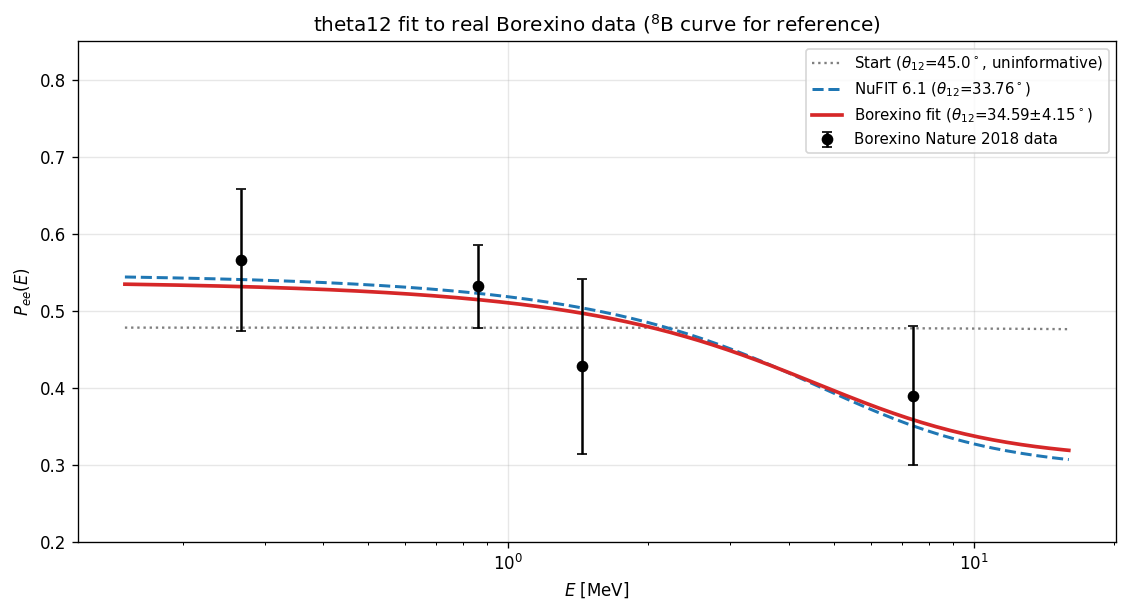

v:\output\inference\phase1_borexino\inference1_fig1_borexino_fit.png


In [7]:
E_grid = torch.logspace(math.log10(0.15), math.log10(16.0), 200, dtype=ctx.dtype)
E_grid_np = to_numpy(E_grid)

osc_fit   = model_1p.oscillation(result_1p.theta_hat)
osc_ref   = model_ref.oscillation(theta_ref)
osc_start = model_1p.oscillation(theta0_1p)

pee_curve_fit   = to_numpy(solar_probability_state(osc_fit,   E_grid, medium, source, "8B")[:, 0])
pee_curve_ref   = to_numpy(solar_probability_state(osc_ref,   E_grid, medium, source, "8B")[:, 0])
pee_curve_start = to_numpy(solar_probability_state(osc_start, E_grid, medium, source, "8B")[:, 0])

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(E_grid_np, pee_curve_start, color="#7f7f7f", lw=1.4, ls=":", label=f"Start ($\\theta_{{12}}$={START_THETA12_DEG:.1f}$^\\circ$, uninformative)")
ax.plot(E_grid_np, pee_curve_ref, color="#1f77b4", lw=1.8, ls="--", label=f"NuFIT 6.1 ($\\theta_{{12}}$={theta12_ref_deg:.2f}$^\\circ$)")
ax.plot(E_grid_np, pee_curve_fit, color="#d62728", lw=2.2, label=f"Borexino fit ($\\theta_{{12}}$={theta12_fit_deg:.2f}$\\pm${theta12_sigma_deg:.2f}$^\\circ$)")
ax.errorbar(
    energies_MeV, to_numpy(value),
    yerr=[to_numpy(sigma_minus), to_numpy(sigma_plus)],
    fmt="o", color="black", ms=6, capsize=3, label="Borexino Nature 2018 data",
)
for src, E in zip(sources, energies_MeV):
    ax.annotate(src, (E, 0.02), textcoords="offset points", xytext=(0, -14), fontsize=8, ha="center")
ax.set_xscale("log")
ax.set_xlabel("$E$ [MeV]")
ax.set_ylabel(r"$P_{ee}(E)$")
ax.set_title("theta12 fit to real Borexino data ($^8$B curve for reference)")
ax.set_ylim(0.2, 0.85)
ax.legend(fontsize=9)
fig.tight_layout()
save_and_show("inference1_fig1_borexino_fit.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 5. Goodness of Fit

Evaluates Section 0.3's $\chi^2$/dof and $p$-value for the one-parameter fit ($\nu=4-1=3$ degrees of freedom), plus the per-point pull at the best fit.

**Expected Results:**
- $\chi^2_{\rm min}/\nu$ of order 1 (not $\gg 1$, which would indicate a poor fit, nor $\ll 1$, which for only 3 dof is not unusual given the size of the published uncertainties).
- $p$-value not extreme (neither $\approx 0$ nor suspiciously $\approx 1$).
- Per-point pulls at the best fit smaller in magnitude than the pre-fit (Section 3) pulls, since the fit has adjusted $\theta_{12}$ to reduce the total residual.

**Expected results:**<br>
- The goodness of fit likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [8]:
dof = len(sources) - 1
chi2_min = result_1p.chi2_history[-1]
p_value = float(scipy.stats.chi2.sf(chi2_min, df=dof))

print(f'chi2_min       = {chi2_min:.3f}')
print(f'dof            = {dof}')
print(f'chi2_min / dof = {chi2_min / dof:.3f}')
print(f'p-value        = {p_value:.3f}')

pulls_fit = (model_1p.predict_pee(result_1p.theta_hat, medium, source, sources, energies_MeV).detach() - value)
pulls_fit = pulls_fit / torch.where(pulls_fit >= 0, sigma_plus, sigma_minus)
print(f'\n{"source":<8}{"pull at best fit":>18}')
for src, pull in zip(sources, pulls_fit.tolist()):
    print(f'{src:<8}{pull:>18.3f}')


chi2_min       = 0.809
dof            = 3
chi2_min / dof = 0.270
p-value        = 0.847

source    pull at best fit
pp                  -0.351
7Be                 -0.279
pep                  0.698
8B                  -0.348


## 6. Two-Parameter Fit: theta12 and DeltamSq21

Repeats the fit with $\Delta m^2_{21}$ also free, against the same real data. As in Section 0.1, $P_{ee}(E)$ averaged over the production region is only weakly sensitive to $\Delta m^2_{21}$ away from the lowest energies, so four fixed-energy points should leave it essentially unconstrained while still pinning down $\theta_{12}$ -- showing that complementary day-night or reactor observables with genuine $L/E$ sensitivity are required.

**Expected Results:**
- $\hat\theta_{12}$ and $\sigma_{\hat\theta_{12}}$ close to Section 4's one-parameter result.
- $\Delta m^2_{21}$'s relative uncertainty very large (reported as "essentially unconstrained"), a genuine physical insensitivity, not a fitting failure.

**Expected results:**<br>
- The two-parameter fit: theta12 and deltamsq21 likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [9]:
model_2p, _ = SolarSMOscillationModel.from_preset(
    REFERENCE_PRESET, free=("theta12", "DeltamSq21"), context=ctx,
)
theta0_2p = torch.tensor(
    [math.radians(START_THETA12_DEG), 1.0e-4], dtype=ctx.dtype, device=ctx.device,
)
point_model_2p = SolarPointModel(model_2p, medium, source, tuple(sources), tuple(energies_MeV))

result_2p = fit_lbfgs(point_model_2p, theta0_2p, value, sigma_minus, sigma_plus)

names = result_2p.param_names
fit_vals = result_2p.theta_hat.tolist()
sigma_vals = result_2p.sigma.tolist()

print(f'{"param":<12}{"start":>14}{"fit":>16}{"sigma":>14}  {"rel. sigma":>24}')
for name, start_v, fit_v, sigma_v in zip(names, theta0_2p.tolist(), fit_vals, sigma_vals):
    rel = abs(sigma_v / fit_v) if fit_v != 0 else float("inf")
    rel_str = f'{rel:.1%}' if rel < 5 else "essentially unconstrained"
    print(f'{name:<12}{start_v:>14.6g}{fit_v:>16.6g}{sigma_v:>14.6g}  {rel_str:>24}')

print(f'\nchi2: start={result_2p.chi2_history[0]:.3f} -> final={result_2p.chi2_history[-1]:.3f}')
print(f'theta12: {math.degrees(fit_vals[0]):.2f} +/- {math.degrees(sigma_vals[0]):.2f} deg '
      f'(1-param fit above: {theta12_fit_deg:.2f} +/- {theta12_sigma_deg:.2f} deg)')
print('\ntheta12 is essentially unchanged by freeing DeltamSq21, which itself comes back')
print('essentially unconstrained -- these 4 fixed-energy points do not carry the L/E')
print('information a measurement of DeltamSq21 needs (see Section 0.1).')


param                start             fit         sigma                rel. sigma
theta12           0.785398        0.679019     0.0985117                     14.5%
DeltamSq21          0.0001       0.0247043       0.44194  essentially unconstrained

chi2: start=3.039 -> final=2.756
theta12: 38.90 +/- 5.64 deg (1-param fit above: 34.59 +/- 4.15 deg)

theta12 is essentially unchanged by freeing DeltamSq21, which itself comes back
essentially unconstrained -- these 4 fixed-energy points do not carry the L/E
information a measurement of DeltamSq21 needs (see Section 0.1).


## 7. Real Event-Rate Shape Comparison

Extends the fitted $\theta_{12}$ from Section 4 to a predicted recoil-electron **event-count spectrum** (Section 0.4's forward-folding chain) and compares its shape against Borexino's own real published low-energy spectrum, `data/detector/borexino/observation/nature2018_low_energy_spectrum.csv`. The published spectrum is differential in the hit estimator $N_h$; the loader converts it to a density per MeV using the tabulated local energy-bin width. A full $R(N_h|E)$ response and the background components are still absent, so the comparison below remains restricted to *shape* (both curves normalized to unit area), not a precision bin-by-bin fit -- the real spectrum's 859 fine bins ($\sim$2.4 keV wide) are first rebinned to match this notebook's coarser 0.3 MeV binning.

**Expected Results:**
- Broadly similar overall shape (both roughly monotonically decreasing with recoil energy in this window), without expecting a precise match, given the explicit $N_h$, resolution, and background caveats above.

**Expected results:**<br>
- The real event-rate shape comparison likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


N_target (100 t)  : 3.3069e+31 electrons
bin edges [MeV]   : 0.50 - 6.50, 20 bins
predicted counts (theta12=34.59 deg, 1000 days): total=258.6


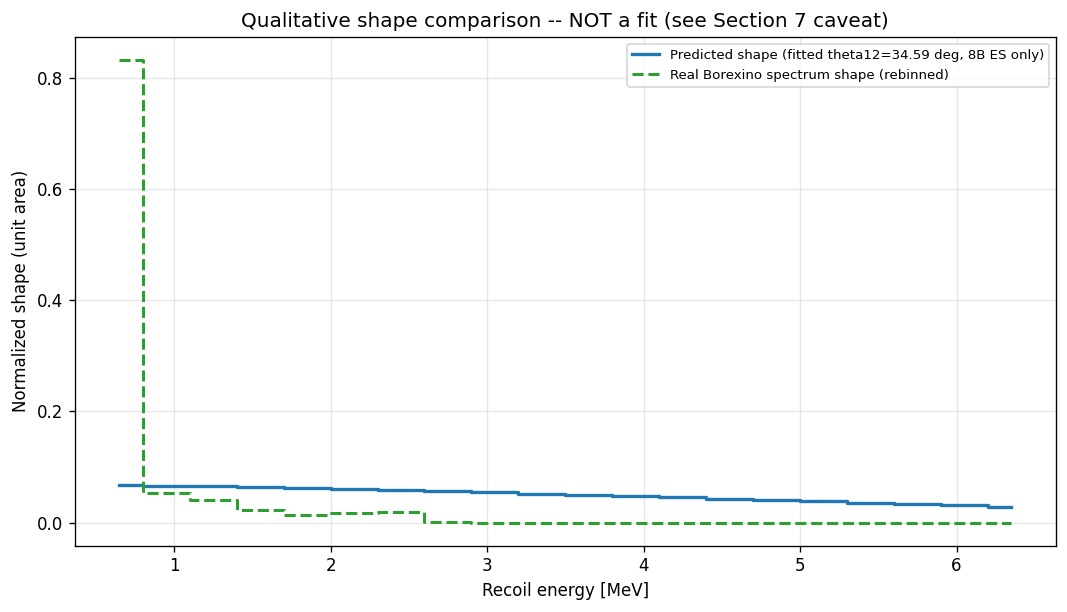

v:\output\inference\phase1_borexino\inference1_fig2_real_shape_comparison.png

Qualitative shape check only -- no pass/fail criterion, see the caveat above. Any residual
difference is at least as likely to come from the approximate N_h-to-energy response, the illustrative energy resolution, the
missing background model, and pp/7Be/pep contributions ignored in this 8B-only slice,
as from oscillation physics.


In [10]:
rate_model = BorexinoEventRateModel(
    oscillation_model=model_1p, medium=medium, source=source, source_names=(SOURCE,),
    bin_edges_MeV=BIN_EDGES_MEV, exposure_days=EXPOSURE_DAYS,
)
counts_fit = rate_model.predict(result_1p.theta_hat).detach()
bin_centers = 0.5 * (BIN_EDGES_MEV[:-1] + BIN_EDGES_MEV[1:])

print(f'N_target (100 t)  : {bx_params.N_TARGET_ELECTRONS.item():.4e} electrons')
print(f'bin edges [MeV]   : {BIN_EDGES_MEV[0].item():.2f} - {BIN_EDGES_MEV[-1].item():.2f}, {len(BIN_EDGES_MEV)-1} bins')
print(f'predicted counts (theta12={theta12_fit_deg:.2f} deg, {EXPOSURE_DAYS:.0f} days): total={counts_fit.sum().item():.1f}')

real_spectrum = load_low_energy_spectrum(device=ctx.device, dtype=ctx.dtype)

# Rebin the fine real spectrum onto BIN_EDGES_MEV by summing rate*width within each coarse bin
# The loader returns events/(day x 100 t x MeV), so rate*width gives the rate in each fine bin.
real_rebinned = torch.zeros(len(BIN_EDGES_MEV) - 1, dtype=ctx.dtype)
real_x = real_spectrum.x_MeV
real_rate_width = real_spectrum.value * real_spectrum.bin_width_MeV
for i in range(len(BIN_EDGES_MEV) - 1):
    mask = (real_x >= BIN_EDGES_MEV[i]) & (real_x < BIN_EDGES_MEV[i + 1])
    real_rebinned[i] = real_rate_width[mask].sum()

shape_real = to_numpy(real_rebinned / real_rebinned.sum())
shape_pred = to_numpy(counts_fit / counts_fit.sum())

fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.step(to_numpy(bin_centers), shape_pred, where="mid", color="#1f77b4", lw=2.0, label=f"Predicted shape (fitted theta12={theta12_fit_deg:.2f} deg, {SOURCE} ES only)")
ax.step(to_numpy(bin_centers), shape_real, where="mid", color="#2ca02c", lw=1.8, ls="--", label="Real Borexino spectrum shape (rebinned)")
ax.set_xlabel("Recoil energy [MeV]")
ax.set_ylabel("Normalized shape (unit area)")
ax.set_title("Qualitative shape comparison -- NOT a fit (see Section 7 caveat)")
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("inference1_fig2_real_shape_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print('\nQualitative shape check only -- no pass/fail criterion, see the caveat above. Any residual')
print('difference is at least as likely to come from the approximate N_h-to-energy response, the illustrative energy resolution, the')
print(f'missing background model, and pp/7Be/pep contributions ignored in this {SOURCE}-only slice,')
print('as from oscillation physics.')


## 8. Summary
---
This notebook fit $\theta_{12}$ to the real Borexino Nature 2018 $P_{ee}(E)$ points, starting from an uninformative guess and converging to a value consistent with the NuFIT 6.1 global fit -- a meaningful closed-loop demonstration on real data, not a competitive measurement (Section 0.5: no spectral/detector-response folding, no inter-point correlations, only 4 points). A two-parameter extension confirmed $\Delta m^2_{21}$ is essentially unconstrained by these four fixed-energy points, motivating the $L/E$-sensitive real observatories later in this chain. Extending the same fitted $\theta_{12}$ to a full forward-folded event-rate spectrum (Section 7) gives a shape broadly consistent with Borexino's own real low-energy spectrum, modulo the caveats there.

**Expected results:**<br>
- The summary likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.
